<h2 style="text-align:center;">📊 ReviewLens: Sentiment Mining from Restaurant Feedback</h2>


### 📌 Introduction
- **Objective**: Analyze restaurant reviews and classify them into **Positive** or **Negative** sentiments.  
- **Business Use Case**:  
  Restaurants receive thousands of customer reviews. Manually analyzing them is time-consuming.  
  Using **NLP + ML**, we can build a system to:  
  - Automatically detect customer sentiment.  
  - Provide insights into service quality, food satisfaction, and areas of improvement.  

### 🔹 Approach
1. Dataset Loading & Exploration  
2. Text Preprocessing (cleaning, stemming, stopwords)  
3. Feature Extraction (BoW, TF-IDF, n-grams)  
4. Model Training (Logistic Regression, Naive Bayes, SVM, RandomForest, Decision Tree, XGBoost, LightGBM)  
5. Model Evaluation (accuracy, precision, recall, f1-score, ROC-AUC)  
6. Business Insights & Conclusion  


In [4]:
# ➤ Importing essential libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# For preprocessing
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

# For feature extraction & ML
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier


#### Load Dataset & EDA

In [2]:
# ➤ Load dataset
df = pd.read_csv("data/Restaurant_Reviews.tsv", delimiter='\t', quoting=3)

# Quick look
print(df.shape)
df.head()


(1000, 2)


,Review,Liked
0,Wow... Loved this place.,1
1,Crust is not good.,0
2,Not tasty and the texture was just nasty.,0
3,Stopped by during the late May bank holiday of...,1
4,The selection on the menu was great and so wer...,1


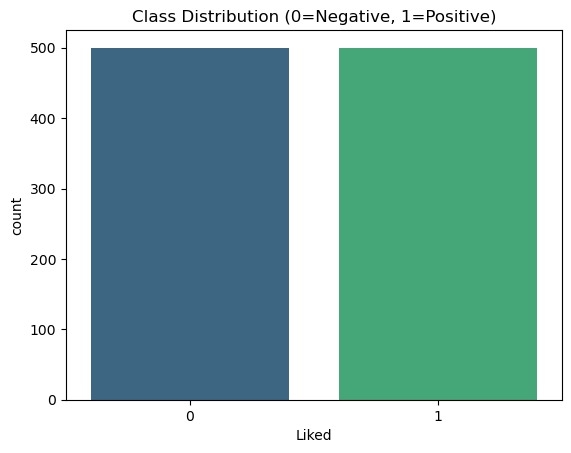

Liked
1    0.5
0    0.5
Name: proportion, dtype: float64

In [5]:
# ➤ Check class distribution
sns.countplot(x="Liked", data=df, palette="viridis")
plt.title("Class Distribution (0=Negative, 1=Positive)")
plt.show()

df["Liked"].value_counts(normalize=True)


#### Text Preprocessing

In [7]:
# Download stopwords
# nltk.download("stopwords")

ps = PorterStemmer()
corpus = []

for review in df["Review"]:
    # Remove non-alphabetical characters
    review = re.sub("[^a-zA-Z]", " ", review)
    review = review.lower().split()
    
    # Remove stopwords & apply stemming
    review = [ps.stem(word) for word in review if word not in stopwords.words("english")]
    review = " ".join(review)
    corpus.append(review)

print("Sample cleaned review:", corpus[0])


Sample cleaned review: wow love place


#### Feature Extraction (BoW & TF-IDF)

In [8]:
# ➤ Bag of Words
cv = CountVectorizer(max_features=1500, ngram_range=(1,2))  # include bigrams
X_bow = cv.fit_transform(corpus).toarray()

# ➤ TF-IDF
tfidf = TfidfVectorizer(max_features=1500, ngram_range=(1,2))
X_tfidf = tfidf.fit_transform(corpus).toarray()

# Target variable
y = df["Liked"].values


#### Train-Test Split

In [9]:
X_train_bow, X_test_bow, y_train, y_test = train_test_split(X_bow, y, test_size=0.2, random_state=42)
X_train_tfidf, X_test_tfidf, _, _ = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)


#### Helper Function for Model Training

In [10]:
def evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title("Confusion Matrix")
    plt.show()


#### Train Multiple Models

===== Results with TF-IDF =====

🔹 Logistic Regression
Accuracy: 0.735
ROC-AUC: 0.7387820512820513

Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.83      0.75        96
           1       0.81      0.64      0.72       104

    accuracy                           0.73       200
   macro avg       0.75      0.74      0.73       200
weighted avg       0.75      0.73      0.73       200



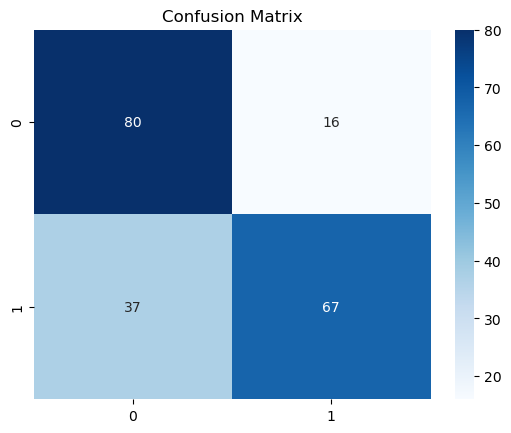


🔹 Naive Bayes
Accuracy: 0.77
ROC-AUC: 0.7708333333333333

Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.79      0.77        96
           1       0.80      0.75      0.77       104

    accuracy                           0.77       200
   macro avg       0.77      0.77      0.77       200
weighted avg       0.77      0.77      0.77       200



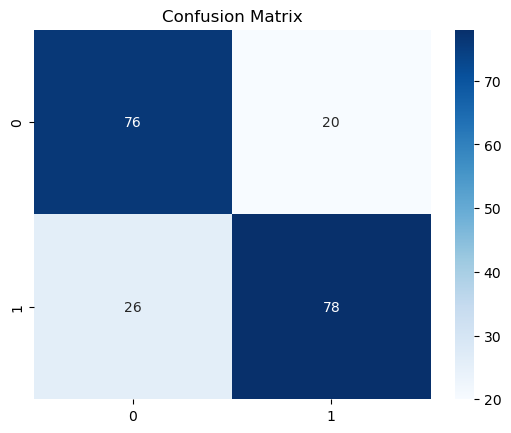


🔹 SVM
Accuracy: 0.75
ROC-AUC: 0.7544070512820512

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.86      0.77        96
           1       0.84      0.64      0.73       104

    accuracy                           0.75       200
   macro avg       0.76      0.75      0.75       200
weighted avg       0.77      0.75      0.75       200



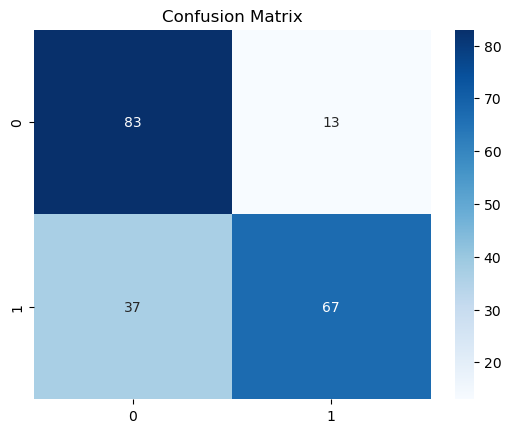


🔹 Decision Tree
Accuracy: 0.715
ROC-AUC: 0.71875

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.81      0.73        96
           1       0.78      0.62      0.70       104

    accuracy                           0.71       200
   macro avg       0.72      0.72      0.71       200
weighted avg       0.73      0.71      0.71       200



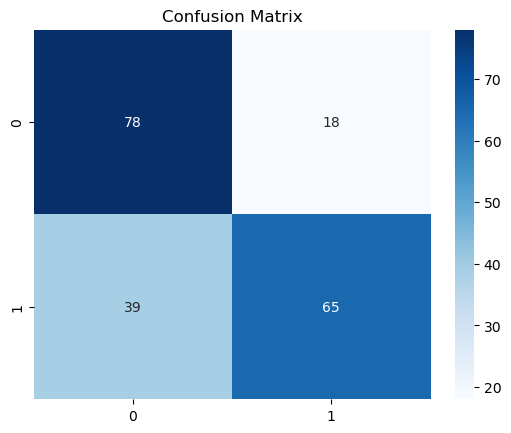


🔹 Random Forest
Accuracy: 0.72
ROC-AUC: 0.7243589743589745

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.83      0.74        96
           1       0.80      0.62      0.70       104

    accuracy                           0.72       200
   macro avg       0.73      0.72      0.72       200
weighted avg       0.74      0.72      0.72       200



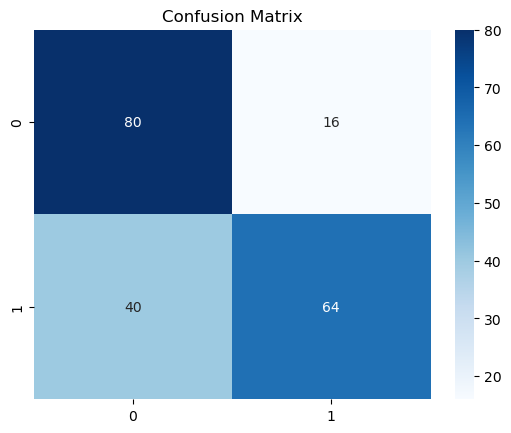


🔹 XGBoost
Accuracy: 0.665
ROC-AUC: 0.6702724358974359

Classification Report:
               precision    recall  f1-score   support

           0       0.62      0.80      0.70        96
           1       0.75      0.54      0.63       104

    accuracy                           0.67       200
   macro avg       0.68      0.67      0.66       200
weighted avg       0.68      0.67      0.66       200



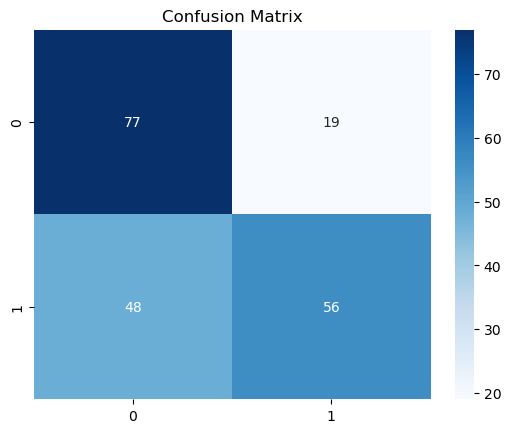


🔹 LightGBM
[LightGBM] [Info] Number of positive: 396, number of negative: 404
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000351 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 316
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 23
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.495000 -> initscore=-0.020001
[LightGBM] [Info] Start training from score -0.020001
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

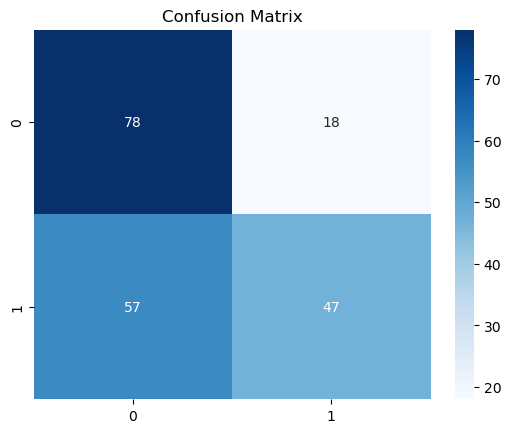

In [11]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Naive Bayes": MultinomialNB(),
    "SVM": SVC(probability=True),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="logloss"),
    "LightGBM": LGBMClassifier()
}

print("===== Results with TF-IDF =====")
for name, model in models.items():
    print(f"\n🔹 {name}")
    evaluate_model(model, X_train_tfidf, X_test_tfidf, y_train, y_test)


<h2 style="text-align:center;">✅ Project Summary – ReviewLens</h2>

- We built an **NLP-based Sentiment Classifier** for restaurant reviews.  
- Workflow: **Cleaning → Preprocessing → Feature Extraction (BoW/TF-IDF) → Modeling → Evaluation**.  

### 🔹 Key Findings
- **Logistic Regression / Naive Bayes** often perform best on text classification.  
- **XGBoost / LightGBM** can give strong results with tuning.  
- **Decision Tree** may underfit (low accuracy).  

### 🔹 Business Value
- Restaurant managers can:  
  - Monitor customer satisfaction in real time.  
  - Detect recurring complaints and improve service.  
  - Automate review analysis instead of manual reading.  

### 🔹 Next Steps
- Hyperparameter tuning with GridSearchCV.  
- Try **Word Embeddings (Word2Vec, GloVe, FastText)**.  
- Apply **Deep Learning (LSTM, BERT, Transformers)** for state-of-the-art performance.  


### 🔹 Results Summary
- **Best Model:** Naive Bayes with TF-IDF (Accuracy: 77%, ROC-AUC: 0.77).  
- Linear models (Naive Bayes, Logistic Regression, SVM) worked better than tree-based methods.  
- Decision Trees, Random Forest, XGBoost, and LightGBM underperformed without tuning.  

### 🔹 Next Steps
- Perform **hyperparameter tuning** to improve accuracy.  
- Try higher-dimensional TF-IDF with n-grams.  
- Explore **deep learning (LSTM, BERT)** for advanced benchmarks.  

✅ With this, we’ve built a **baseline sentiment analysis system** that already performs decently and can be deployed after optimization.
